# Baseline vs Fine-Tuned Evaluation: Qwen2.5-VL-7B

**Goal**: Compare the base Qwen2.5-VL-7B-Instruct against the QLoRA fine-tuned model on the same held-out test set.

| Metric | What It Measures |
|--------|------------------|
| **JSON Schema Compliance** | % of outputs that parse as valid JSON matching the target schema |
| **Scene Type Accuracy** | Exact-match classification accuracy |
| **ROUGE-L** | N-gram overlap between generated and reference captions |
| **BERTScore** | Semantic similarity between generated and reference captions |
| **Object Mention F1** | Precision/recall on predicted object types vs. ground truth |

**Approach**: Load base model → run inference → compute metrics → load LoRA adapter → repeat → compare side by side.

In [1]:
%%capture
!pip install "transformers>=4.49" peft bitsandbytes qwen-vl-utils accelerate \
    rouge-score bert-score scikit-learn matplotlib

In [ ]:
import json, time, sys
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from google.colab import drive

# ── Import shared modules ───────────────────────────────────────
DRIVE_PROJECT = Path("/content/drive/MyDrive/vlm-scene-analyser")
sys.path.insert(0, str(DRIVE_PROJECT))

from src.prompts import SYSTEM_PROMPT, USER_PROMPT
from src.inference import load_model, run_inference, extract_json, validate_schema
from src.evaluation import compute_all_metrics, extract_object_types

# ── Config ──────────────────────────────────────────────────────
QWEN_MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
ADAPTER_PATH = DRIVE_PROJECT / "models" / "qwen_lora_v1"
TEST_SPLIT_PATH = ADAPTER_PATH / "test_split.jsonl"
IMAGE_DIR = Path("/content/images/nadir")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# ── Inference helper (loops over test set) ───────────────────
from qwen_vl_utils import process_vision_info


def run_test_inference(model, processor, test_ann):
    """Run inference on all test samples and return predictions list."""
    predictions = []
    for i, ann in enumerate(test_ann):
        raw = run_inference(model, processor, ann["image_path"])
        predictions.append({
            "image_file": ann["image_file"],
            "scene_type_gt": ann["scene_type"],
            "caption_gt": ann["caption"],
            "objects_gt": ann["objects"],
            "infrastructure_gt": ann["infrastructure"],
            "terrain_gt": ann["terrain"],
            "raw_prediction": raw,
        })
        print(f"[{i+1}/{len(test_ann)}] {ann['image_file'][:40]}... done")

    print(f"\nGenerated {len(predictions)} predictions.")
    return predictions


print("Utilities loaded (from src/).")

In [ ]:
# ── Load base model + test split ─────────────────────────────
import shutil

drive.mount("/content/drive")

# Copy images locally for faster I/O
if not IMAGE_DIR.exists():
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    for f in (DRIVE_PROJECT / "images" / "nadir").glob("*.jpg"):
        shutil.copy2(f, IMAGE_DIR / f.name)

# Load base model (4-bit NF4, no adapter)
print(f"Loading {QWEN_MODEL_ID} (4-bit NF4)...")
base_model, processor = load_model(QWEN_MODEL_ID, quantize_4bit=True)
print("Base model loaded.")

# Load test split
test_ann = []
with open(TEST_SPLIT_PATH) as f:
    for line in f:
        ann = json.loads(line)
        ann["image_path"] = str(IMAGE_DIR / ann["image_file"])
        test_ann.append(ann)

print(f"Test set: {len(test_ann)} samples")
print(f"Scene types: {Counter(a['scene_type'] for a in test_ann)}")

## Phase 1: Baseline (no LoRA)

In [ ]:
# ── Baseline inference (cached) ──────────────────────────────
BASELINE_CACHE = DRIVE_PROJECT / "models" / "baseline_predictions.json"

if BASELINE_CACHE.exists():
    with open(BASELINE_CACHE) as f:
        baseline_predictions = json.load(f)

    # Validate cache matches current test split
    cached_files = [p["image_file"] for p in baseline_predictions]
    test_files = [a["image_file"] for a in test_ann]

    if cached_files != test_files:
        print("Test split changed — re-running baseline inference...")
        baseline_predictions = run_test_inference(base_model, processor, test_ann)
        with open(BASELINE_CACHE, "w") as f:
            json.dump(baseline_predictions, f, indent=2, ensure_ascii=False)
        print(f"Cache updated: {BASELINE_CACHE}")
    else:
        print(f"Loaded {len(baseline_predictions)} cached baseline predictions")
        # Update GT fields from current annotations (captions may have changed)
        for pred, ann in zip(baseline_predictions, test_ann):
            pred["caption_gt"] = ann["caption"]
            pred["scene_type_gt"] = ann["scene_type"]
            pred["objects_gt"] = ann["objects"]
            pred["infrastructure_gt"] = ann["infrastructure"]
            pred["terrain_gt"] = ann["terrain"]
else:
    print("No cached baseline found — running baseline inference...")
    baseline_predictions = run_test_inference(base_model, processor, test_ann)
    with open(BASELINE_CACHE, "w") as f:
        json.dump(baseline_predictions, f, indent=2, ensure_ascii=False)
    print(f"Saved to {BASELINE_CACHE}")

In [6]:
# ── Baseline metrics ─────────────────────────────────────────
print("Computing baseline metrics...\n")
baseline_metrics = compute_all_metrics(baseline_predictions, device=base_model.device)

print("=" * 50)
print("  BASELINE RESULTS")
print("=" * 50)
for k, v in baseline_metrics.items():
    if not k.startswith("_"):
        print(f"  {k:30s} {v}")
print("=" * 50)

# Schema compliance details
print("\nSchema compliance:")
for r in baseline_metrics["_details"]["schema_results"]:
    status = "OK" if r["valid"] else r["error"]
    print(f"  {r['image'][:45]:45s} {status}")

# Scene type confusion
print("\nScene type confusion:")
for gt, preds in sorted(baseline_metrics["_details"]["confusion"].items()):
    for predicted, count in sorted(preds.items(), key=lambda x: -x[1]):
        marker = "  +" if gt == predicted else "  x"
        print(f"  {gt:25s} -> {predicted:25s} {count}{marker}")

Computing baseline metrics...



config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BASELINE RESULTS
  schema_compliance_pct          100.0
  scene_type_accuracy_pct        76.5
  rouge1_f1                      0.3338
  rouge2_f1                      0.0494
  rougeL_f1                      0.1937
  bertscore_f1                   0.877
  object_mention_f1              0.2954

Schema compliance:
  nadir_industrial_woodlands_industrial_1.4519_ OK
  nadir_parks_gardens_by_bay_1.2816_103.8636.jp OK
  nadir_commercial_kampong_glam_1.3017_103.8594 OK
  nadir_commercial_harbourfront_1.265_103.822.j OK
  nadir_hdb_hougang_1.3707_103.8804.jpg         OK
  nadir_mixed_marine_parade_vjc_1.3059_103.9198 OK
  nadir_industrial_tuas_1.3255_103.645.jpg      OK
  nadir_transport_woodlands_ckpt_1.447_103.769. OK
  nadir_airport_seletar_1.4167_103.8675.jpg     OK
  nadir_mixed_jurong_lake_district_1.332_103.73 OK
  nadir_port_marina_south_pier_1.27_103.863.jpg OK
  nadir_mixed_geylang_1.317_103.888.jpg         OK
  nadir_port_tanjong_pagar_terminal_1.267_103.8 OK
  nadir_hdb_pasir_ris_

## Phase 2: Fine-tuned (with LoRA)

In [ ]:
# ── Load LoRA adapter ────────────────────────────────────────
from peft import PeftModel

print(f"Loading LoRA adapter from {ADAPTER_PATH}...")
ft_model = PeftModel.from_pretrained(base_model, str(ADAPTER_PATH))
ft_model.eval()
print("Fine-tuned model loaded.")

In [ ]:
# ── Fine-tuned inference ─────────────────────────────────────
print("Running fine-tuned inference (with LoRA)...")
finetuned_predictions = run_test_inference(ft_model, processor, test_ann)

In [9]:
# ── Fine-tuned metrics ───────────────────────────────────────
print("Computing fine-tuned metrics...\n")
finetuned_metrics = compute_all_metrics(finetuned_predictions, device=ft_model.device)

print("=" * 50)
print("  FINE-TUNED RESULTS")
print("=" * 50)
for k, v in finetuned_metrics.items():
    if not k.startswith("_"):
        print(f"  {k:30s} {v}")
print("=" * 50)

# Schema compliance details
print("\nSchema compliance:")
for r in finetuned_metrics["_details"]["schema_results"]:
    status = "OK" if r["valid"] else r["error"]
    print(f"  {r['image'][:45]:45s} {status}")

# Scene type confusion
print("\nScene type confusion:")
for gt, preds in sorted(finetuned_metrics["_details"]["confusion"].items()):
    for predicted, count in sorted(preds.items(), key=lambda x: -x[1]):
        marker = "  +" if gt == predicted else "  x"
        print(f"  {gt:25s} -> {predicted:25s} {count}{marker}")

Computing fine-tuned metrics...



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  FINE-TUNED RESULTS
  schema_compliance_pct          100.0
  scene_type_accuracy_pct        76.5
  rouge1_f1                      0.5563
  rouge2_f1                      0.2353
  rougeL_f1                      0.3861
  bertscore_f1                   0.9136
  object_mention_f1              0.3951

Schema compliance:
  nadir_industrial_woodlands_industrial_1.4519_ OK
  nadir_parks_gardens_by_bay_1.2816_103.8636.jp OK
  nadir_commercial_kampong_glam_1.3017_103.8594 OK
  nadir_commercial_harbourfront_1.265_103.822.j OK
  nadir_hdb_hougang_1.3707_103.8804.jpg         OK
  nadir_mixed_marine_parade_vjc_1.3059_103.9198 OK
  nadir_industrial_tuas_1.3255_103.645.jpg      OK
  nadir_transport_woodlands_ckpt_1.447_103.769. OK
  nadir_airport_seletar_1.4167_103.8675.jpg     OK
  nadir_mixed_jurong_lake_district_1.332_103.73 OK
  nadir_port_marina_south_pier_1.27_103.863.jpg OK
  nadir_mixed_geylang_1.317_103.888.jpg         OK
  nadir_port_tanjong_pagar_terminal_1.267_103.8 OK
  nadir_hdb_pasir_r

## Comparison

In [10]:
# ── Side-by-side comparison table ─────────────────────────────

metric_keys = [
    ("schema_compliance_pct", "Schema Compliance (%)"),
    ("scene_type_accuracy_pct", "Scene Type Accuracy (%)"),
    ("rouge1_f1", "ROUGE-1 F1"),
    ("rouge2_f1", "ROUGE-2 F1"),
    ("rougeL_f1", "ROUGE-L F1"),
    ("bertscore_f1", "BERTScore F1"),
    ("object_mention_f1", "Object Mention F1"),
]

print("=" * 70)
print("  EVALUATION COMPARISON — Qwen2.5-VL-7B")
print("=" * 70)
print(f"  {'Metric':28s} {'Baseline':>10s} {'Fine-tuned':>12s} {'Delta':>10s}")
print("  " + "-" * 62)

for key, label in metric_keys:
    b = baseline_metrics[key]
    f = finetuned_metrics[key]
    delta = f - b
    sign = "+" if delta >= 0 else ""

    if "pct" in key:
        print(f"  {label:28s} {b:>9.1f}% {f:>11.1f}% {sign}{delta:>8.1f}%")
    else:
        print(f"  {label:28s} {b:>10.4f} {f:>12.4f} {sign}{delta:>9.4f}")

print("=" * 70)

  EVALUATION COMPARISON — Qwen2.5-VL-7B
  Metric                         Baseline   Fine-tuned      Delta
  --------------------------------------------------------------
  Schema Compliance (%)            100.0%       100.0% +     0.0%
  Scene Type Accuracy (%)           76.5%        76.5% +     0.0%
  ROUGE-1 F1                       0.3338       0.5563 +   0.2225
  ROUGE-2 F1                       0.0494       0.2353 +   0.1859
  ROUGE-L F1                       0.1937       0.3861 +   0.1924
  BERTScore F1                     0.8770       0.9136 +   0.0366
  Object Mention F1                0.2954       0.3951 +   0.0997


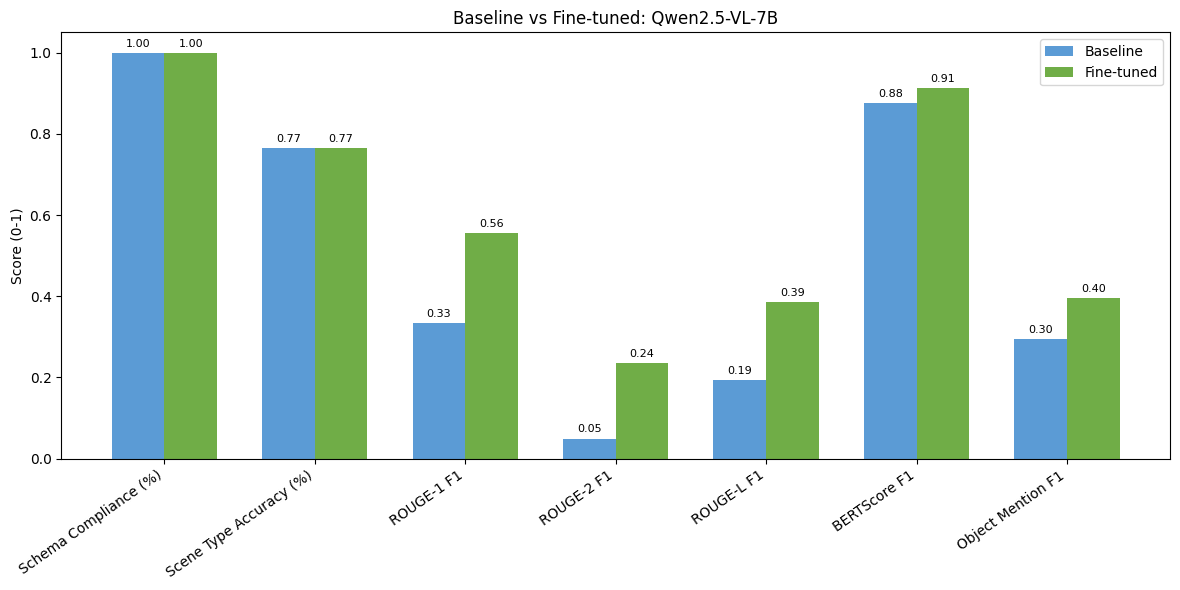

Results saved to evaluation_comparison.json


In [11]:
# ── Comparison bar chart ──────────────────────────────────────

labels = [label for _, label in metric_keys]
baseline_vals = []
finetuned_vals = []

for key, _ in metric_keys:
    b = baseline_metrics[key]
    f = finetuned_metrics[key]
    # Normalise percentage metrics to 0-1 scale
    if "pct" in key:
        b, f = b / 100, f / 100
    baseline_vals.append(b)
    finetuned_vals.append(f)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline", color="#5B9BD5")
bars2 = ax.bar(x + width/2, finetuned_vals, width, label="Fine-tuned", color="#70AD47")

ax.set_ylabel("Score (0-1)")
ax.set_title("Baseline vs Fine-tuned: Qwen2.5-VL-7B")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("baseline_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Export combined results ───────────────────────────────────
combined_results = {
    "n_test": len(test_ann),
    "baseline": {k: v for k, v in baseline_metrics.items() if not k.startswith("_")},
    "finetuned": {k: v for k, v in finetuned_metrics.items() if not k.startswith("_")},
}

with open("evaluation_comparison.json", "w") as f:
    json.dump(combined_results, f, indent=2)
print("Results saved to evaluation_comparison.json")

In [12]:
# ── Side-by-side qualitative comparison ───────────────────────
baseline_parsed = baseline_metrics["_details"]["parsed_preds"]
finetuned_parsed = finetuned_metrics["_details"]["parsed_preds"]

for i, (bp, fp, ann) in enumerate(zip(baseline_predictions, finetuned_predictions, test_ann)):
    b_obj = baseline_parsed[i] or {}
    f_obj = finetuned_parsed[i] or {}

    b_st = b_obj.get("scene_type", "<missing>")
    f_st = f_obj.get("scene_type", "<missing>")
    gt_st = ann["scene_type"]

    b_mark = "+" if b_st == gt_st else "x"
    f_mark = "+" if f_st == gt_st else "x"

    print("=" * 80)
    print(f"[{i+1}/{len(test_ann)}] {ann['image_file']}")
    print("-" * 80)

    print(f"  Scene Type:")
    print(f"    GT:         {gt_st}")
    print(f"    Baseline:   {b_st}  ({b_mark})")
    print(f"    Fine-tuned: {f_st}  ({f_mark})")

    print(f"\n  Caption:")
    print(f"    GT:         {ann['caption']}")
    print(f"    Baseline:   {b_obj.get('caption', '<missing>')}")
    print(f"    Fine-tuned: {f_obj.get('caption', '<missing>')}")

    gt_objs = sorted([f"{o['type']}({o['count']})" for o in ann.get("objects", [])])
    b_objs = sorted([f"{o['type']}({o['count']})" for o in b_obj.get("objects", [])])
    f_objs = sorted([f"{o['type']}({o['count']})" for o in f_obj.get("objects", [])])

    print(f"\n  Objects:")
    print(f"    GT:         {', '.join(gt_objs) or '(none)'}")
    print(f"    Baseline:   {', '.join(b_objs) or '(none)'}")
    print(f"    Fine-tuned: {', '.join(f_objs) or '(none)'}")

print("\n" + "=" * 80)

[1/17] nadir_industrial_woodlands_industrial_1.4519_103.7985.jpg
--------------------------------------------------------------------------------
  Scene Type:
    GT:         industrial
    Baseline:   industrial  (+)
    Fine-tuned: industrial  (+)

  Caption:
    GT:         Industrial estate viewed from above. Warehouses and industrial buildings with grey, blue, and brown rooftops fill the frame, with some featuring rooftop solar panels. Open yards and patches of construction activity are scattered between the buildings. Cleared land and green fields are visible across the estate.
    Baseline:   The image shows a large industrial area with numerous HDB blocks and warehouses spread across the landscape. There are also some green spaces and a few trees scattered throughout the area. A covered walkway can be seen connecting parts of the industrial complex. The terrain appears to be urban with some areas of reclaimed land visible.
    Fine-tuned: Industrial estate viewed from above. D